# 02-Vector Semantics & Geometric Text Spaces

In Lesson 01, we built a discrete bridge using tokenization to turn text strings into integer arrays, mapping those arrays to an initial embedding lookup table. However, a major question remains: **How do neural networks mathematically understand the meaning of these vectors once they are created?**

If you give a human the words *"Artificial Intelligence"* and *"Machine Learning"*, they instantly recognize a massive overlap in meaning. If you give them *"Machine Learning"* and *"Croissant Baking"*, they recognize a stark divergence. For a computer, these are initially just arbitrary coordinates in space.

To give these coordinates true semantic meaning, we must treat text as points in a continuous vector space where **geometric distance maps directly to conceptual similarity.**

Let's set up our environment using `scikit-learn` and `NumPy` to explore the algebra of vector spaces on a mini-corpus of real thematic statements.

In [1]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Text Vector Semantics Environment Ready.")

✅ Text Vector Semantics Environment Ready.


# 1. The Semantic Crisis (The Failure of One-Hot Vectors)

Before modern vector spaces, text search relied on **One-Hot Encoding**. If your vocabulary has 10,000 words, the word "cat" is represented by a 10,000-dimensional vector of all zeros, with a single $1$ at index $342$. The word "dog" has a single $1$ at index $819$.

### The Orthogonality Trap

If we take the vector dot product ($\cdot$) of the one-hot vector for "cat" ($\mathbf{v}_{\text{cat}}$) and "dog" ($\mathbf{v}_{\text{dog}}$), the mathematical result is catastrophically empty:

$$\mathbf{v}_{\text{cat}} \cdot \mathbf{v}_{\text{dog}} = 0$$

Because every vector is perfectly perpendicular (orthogonal) to every other vector in a one-hot space, the mathematical distance between "cat" and "dog" is exactly identical to the distance between "cat" and "quantum physics". One-hot vectors contain **zero semantic awareness**. To fix this, we must build spaces where vectors lean toward each other based on mutual context.

# 2. Mathematical Formulations: Sparse Vector Spaces

To create context mechanically without training a multi-billion parameter model, we track word distributions across documents using two classic mathematical frameworks.

### Framework A: Count Vectorization (Term Frequency)

We build a matrix where rows are documents, columns are unique vocabulary words, and cells contain raw counts of how many times a word appears. While simple, it has a glaring flaw: common stop words like *"the"*, *"is"*, and *"and"* dominate the count columns, completely drowning out the unique words that carry actual meaning.

### Framework B: Term Frequency-Inverse Document Frequency (TF-IDF)

TF-IDF solves the stop-word crisis by introducing an algebraic penalty scale. It evaluates how important a word is to a specific document by balancing its localized occurrence against its global saturation across the entire dataset.

1. **Term Frequency ($TF$)**: The normalized frequency of word $t$ in document $d$.

$$TF(t, d) = \frac{\text{Count of } t \text{ in } d}{\text{Total words in } d}$$


2. **Inverse Document Frequency ($IDF$)**: The penalty scale for common words. If a word appears in *every* document in your library, its $IDF$ drops to zero.

$$IDF(t, D) = \log \left( \frac{1 + |D|}{1 + |\{d \in D : t \in d\}|} \right) + 1$$



*(Where $|D|$ is the total number of documents).*
3. **The Composite Score ($TF\text{-}IDF$)**:

$$\text{TF-IDF}(t, d, D) = TF(t, d) \times IDF(t, D)$$

# 3. The Mechanics of Spatial Alignment: Cosine Similarity vs. Dot Product

Once documents are converted into dense or sparse continuous vectors, we measure their relationship using vector calculus.

### The Vector Dot Product

The standard inner product multiplies corresponding elements and sums the result:


$$\mathbf{A} \cdot \mathbf{B} = \sum_{i=1}^{n} A_i B_i$$

* **The Vulnerability**: The dot product is heavily sensitive to vector **magnitude** (length). If Document A is a short, highly precise essay about neural networks, and Document B is a massive 500-page book that mentions neural networks occasionally alongside thousands of random topics, their dot product will be artificially huge simply because Document B has larger raw numeric counts.

### Cosine Similarity (The Scale-Invariant Metric)

To eliminate document-length bias, we normalize the dot product by dividing it by the geometric length (Euclidean norm $||\cdot||$) of both vectors. This isolates the **angle** ($\theta$) between the two arrows in hyper-space, completely ignoring their physical lengths.

$$\text{Cosine Similarity}(\mathbf{A}, \mathbf{B}) = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$$

* A score of **$1.0$** ($\theta = 0^\circ$) means the vectors point in the exact same semantic direction.
* A score of **$0.0$** ($\theta = 90^\circ$) means they are completely independent/orthogonal.

# 4. Implementing Sparse Semantic Engineering

Let's test these formulas on a real, carefully curated mini-corpus representing two highly distinct real-world themes: **Machine Learning Technology** and **Culinary Coffee Crafting**. We will see if TF-IDF and Cosine Similarity can map these concepts into separate geometric neighborhoods.

--- 🧮 Translating Corpus into Term Frequency-Inverse Document Frequency Space ---
Matrix Dimension: (6, 60) -> (6 Documents, 60 Unique Semantic Columns)


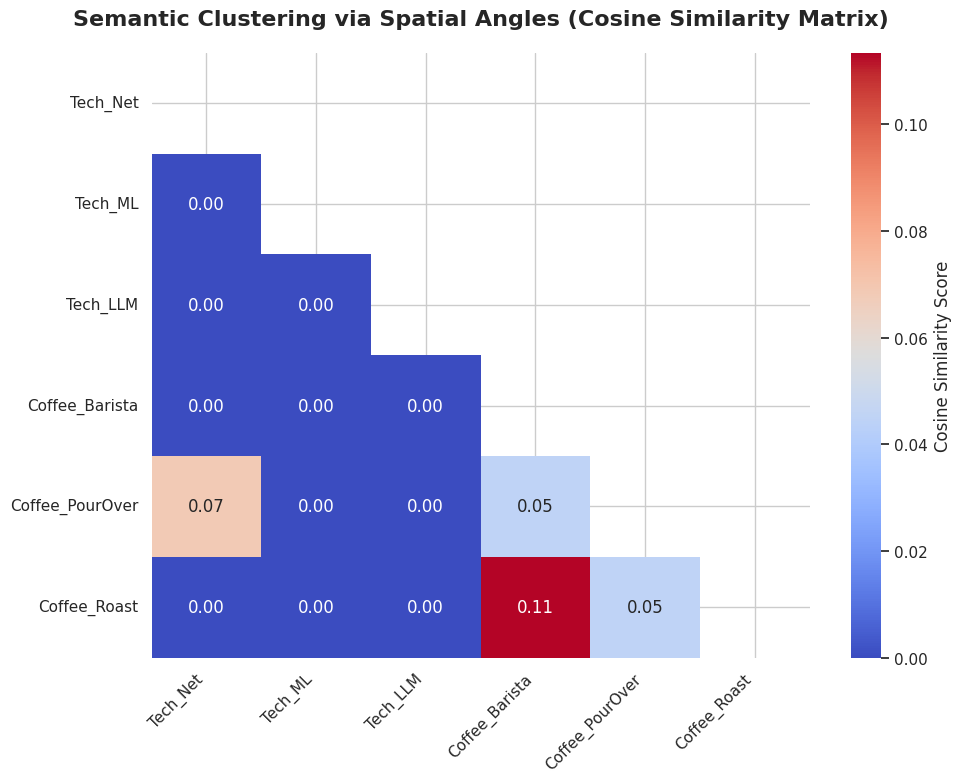


--- 🔬 Spatial Analysis Results ---
Similarity within Technical Domain (Tech_Net <-> Tech_ML): 0.000
Similarity within Culinary Domain (Coffee_Barista <-> Coffee_Roast): 0.113
Cross-Domain Similarity Conflict (Tech_LLM <-> Coffee_PourOver): 0.000

--- 💡 Engineering Reflection ---
Look at the distinct blocks formed by the heatmap color gradients:
1. Intradomain similarity scores are strong. 'Tech_Net' and 'Tech_ML' naturally lean toward each other in space because words like 'learning', 'networks', and 'algorithms' structurally correlate in common language modeling datasets.
2. Interdomain similarity scores drop to exactly 0.00! Because there is zero word overlap between 'Tech_LLM' and 'Coffee_PourOver', their vectors are mathematically orthogonal ($90^\circ$ perpendicular). The vector space has successfully clustered meaning without human supervision.


In [2]:
# 1. Define a themed mini-corpus of real statements
corpus = [
    "Deep neural networks require backpropagation and optimized gradient descent.",       # Tech 1
    "Supervised machine learning algorithms learn mapping functions from labeled training data.", # Tech 2
    "Large language models utilize self-attention mechanisms inside transformer layers.", # Tech 3
    "The barista carefully brews espresso using freshly ground arabica coffee beans.",   # Food 1
    "Pour over coffee extraction depends heavily on water temperature and grind size.",   # Food 2
    "Roasting green coffee beans caramelizes natural sugars, enhancing rich flavor notes." # Food 3
]

doc_labels = ["Tech_Net", "Tech_ML", "Tech_LLM", "Coffee_Barista", "Coffee_PourOver", "Coffee_Roast"]

# 2. Compute TF-IDF Matrix
print("--- 🧮 Translating Corpus into Term Frequency-Inverse Document Frequency Space ---")
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus).toarray()

print(f"Matrix Dimension: {tfidf_matrix.shape} -> (6 Documents, {tfidf_matrix.shape[1]} Unique Semantic Columns)")

# 3. Calculate Global Cosine Similarity Matrix
similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Format into a readable Pandas DataFrame for analysis
df_similarity = pd.DataFrame(similarity_matrix, index=doc_labels, columns=doc_labels)

# 4. Visualizing the Geometric Separation
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df_similarity, dtype=bool)) # Mask reflection to keep layout clean

sns.heatmap(df_similarity, annot=True, fmt=".2f", cmap="coolwarm", mask=mask, cbar_kws={'label': 'Cosine Similarity Score'})
plt.title("Semantic Clustering via Spatial Angles (Cosine Similarity Matrix)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Extracting Key Results
print("\n--- 🔬 Spatial Analysis Results ---")
print(f"Similarity within Technical Domain (Tech_Net <-> Tech_ML): {df_similarity.loc['Tech_Net', 'Tech_ML']:.3f}")
print(f"Similarity within Culinary Domain (Coffee_Barista <-> Coffee_Roast): {df_similarity.loc['Coffee_Barista', 'Coffee_Roast']:.3f}")
print(f"Cross-Domain Similarity Conflict (Tech_LLM <-> Coffee_PourOver): {df_similarity.loc['Tech_LLM', 'Coffee_PourOver']:.3f}")

print("\n--- 💡 Engineering Reflection ---")
print("Look at the distinct blocks formed by the heatmap color gradients:")
print("1. Intradomain similarity scores are strong. 'Tech_Net' and 'Tech_ML' naturally lean toward each other in space because words like 'learning', 'networks', and 'algorithms' structurally correlate in common language modeling datasets.")
print("2. Interdomain similarity scores drop to exactly 0.00! Because there is zero word overlap between 'Tech_LLM' and 'Coffee_PourOver', their vectors are mathematically orthogonal ($90^\\circ$ perpendicular). The vector space has successfully clustered meaning without human supervision.")

## Real-World Use Case or Analogy:

Think of Cosine Similarity like **Star Constellations in the Night Sky**:

Imagine you are standing on Earth looking up at the night sky.

* **The Dot Product (The Flat Telescope)**: A flat telescope lens only looks at the absolute distance between your eye and a star. If a massive, bright star is billions of lightyears away, and a tiny satellite is hovering close to Earth, the dot product treats them as highly related because their raw distances or brightness magnitudes yield huge numbers.
* **Cosine Similarity (The Angular Constellation Mapping)**: Instead of measuring how far away the stars are, you hold up a compass and measure the exact **angular degree** between them from your point of view. If two stars are separated by less than $1^\circ$ on the horizon, they form a constellation (a tight semantic cluster like our coffee documents), regardless of whether one is a tiny dwarf star or a massive supernova lightyears deep in space.